%run evaluate.py

In [6]:
import json
import os
import re

import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# ---------------------------
# Upfront embedding settings
# ---------------------------
MODEL_TYPE = 'ollama'  # 'openai' | 'huggingface' | 'ollama'
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'  # OpenAI/Ollama/HF model id
HIT_THRESHOLD = 0.35  # keep split tokens whose cosine with full-query embedding >= threshold
BATCH_SIZE = 16
BASE_URL = 'http://134.184.22.126:10434'  # used by ollama
API_KEY = os.getenv('OPENAI_API_KEY')  # used by openai
QUESTION_FOLDER = 'D:\\TABLE_DATASET\\DATASET_ABOUT_ADHESIVE\\HGT_IMAGES\\RETRIEVAL_QUESTIONS_with_binary_v1'

MODEL_NAMES = ["Gemma2", "Nomic-embed-text", "Llama3"]
MODEL_THRESHOLD = {
    "Gemma2": 0.54,
    "GPT3.5": 0.30,
    "Nomic-embed-text": 0.30,
    "Llama3": 0.43,
    "deepseek-r1": 0.67
}


EN_STOPWORDS = {
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'has', 'he', 'in',
    'is', 'it', 'its', 'of', 'on', 'that', 'the', 'to', 'was', 'were', 'will', 'with',
    'what', 'which', 'who', 'whom', 'where', 'when', 'why', 'how', 'do', 'does', 'did',
    'can', 'could', 'should', 'would', 'may', 'might', 'into', 'than', 'then', 'or',
}


def _tokenize(text):
    return [tok for tok in re.split(r'\s+', str(text).strip()) if tok]


def _remove_stopwords(text, stopwords=EN_STOPWORDS):
    tokens = _tokenize(text)
    kept = [tok for tok in tokens if tok.lower() not in stopwords]
    return ' '.join(kept) if kept else str(text)


def get_embedding(
    texts,
    model_type=MODEL_TYPE,
    model_name=MODEL_NAME,
    base_url=BASE_URL,
    api_key=API_KEY,
    batch_size=BATCH_SIZE,
):
    """Embed one string or a list of strings with OpenAI, Hugging Face, or Ollama."""
    if isinstance(texts, str):
        texts = [texts]
    texts = [str(text) for text in texts]

    model_type = (model_type or 'huggingface').strip().lower()
    batch_size = max(1, int(batch_size))

    if model_type == 'openai':
        from langchain_openai import OpenAIEmbeddings

        embedder = OpenAIEmbeddings(
            model=model_name or 'text-embedding-3-large',
            api_key=api_key,
        )
    elif model_type == 'huggingface':
        from langchain_huggingface import HuggingFaceEmbeddings

        embedder = HuggingFaceEmbeddings(
            model_name=model_name or 'sentence-transformers/all-MiniLM-L6-v2',
            encode_kwargs={
                'batch_size': batch_size,
                'normalize_embeddings': True,
            },
        )
    elif model_type == 'ollama':
        from langchain_ollama import OllamaEmbeddings

        embedder = OllamaEmbeddings(
            base_url=base_url.rstrip('/'),
            model=model_name or 'nomic-embed-text',
        )
    else:
        raise ValueError(f"Unsupported model_type: {model_type!r}")

    embeddings = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        embeddings.extend(embedder.embed_documents(batch))

    return torch.tensor(embeddings, dtype=torch.float32)


def build_hit_query(query, full_embedding, model_type, model_name, base_url, api_key, batch_size, hit_threshold):
    split_tokens = _tokenize(query)
    if not split_tokens:
        return str(query), torch.empty(0, dtype=torch.float32)

    token_embeddings = get_embedding(
        split_tokens,
        model_type=model_type,
        model_name=model_name,
        base_url=base_url,
        api_key=api_key,
        batch_size=batch_size,
    )

    full_embedding = full_embedding.view(1, -1)
    full_expanded = full_embedding.expand(token_embeddings.size(0), -1)
    cos_scores = F.cosine_similarity(token_embeddings, full_expanded, dim=1)

    # Keep high-informative tokens by cosine score to the full-query embedding.
    keep_mask = cos_scores >= float(hit_threshold)
    kept_tokens = [tok for tok, keep in zip(split_tokens, keep_mask.tolist()) if keep]

    # Fallback: keep at least one token so HIT query is never empty.
    if not kept_tokens:
        best_idx = int(torch.argmax(cos_scores).item())
        kept_tokens = [split_tokens[best_idx]]

    hit_query = ' '.join(kept_tokens)
    return hit_query, cos_scores


def read_questions_and_computer_alpha(
    folder=QUESTION_FOLDER,
    model_type=MODEL_TYPE,
    model_name=MODEL_NAME,
    base_url=BASE_URL,
    api_key=API_KEY,
    batch_size=BATCH_SIZE,
    hit_threshold=HIT_THRESHOLD,
    progress_desc='',
):
    binary_vectors, all_queries = [], []

    for filename in os.listdir(folder):
        if filename.endswith('.json'):
            input_path = os.path.join(folder, filename)
            with open(input_path, 'r', encoding='utf-8') as infile:
                data = json.load(infile)

            queries = data.get('questions', [])
            all_queries.extend([entry.get('question') for entry in queries])
            binary_vectors.extend([entry.get('binary_vector') for entry in queries])

    tag = f"{progress_desc} " if progress_desc else ""
    print(f"  [{tag.strip() or 'progress'}] loaded {len(all_queries)} queries from {folder}")

    # Per-token/split embeddings for each original query.
    print(f"  [{tag.strip() or 'progress'}] (1/4) embedding split tokens per query ...")
    embeding_queries_split_ = [
        get_embedding(
            _tokenize(query),
            model_type=model_type,
            model_name=model_name,
            base_url=base_url,
            api_key=api_key,
            batch_size=batch_size,
        )
        for query in tqdm(all_queries, desc=f"{tag}split", unit="q", leave=False)
    ]

    print(f"  [{tag.strip() or 'progress'}] (2/4) embedding full queries ...")
    embeding_queries_entire_ = get_embedding(
        all_queries,
        model_type=model_type,
        model_name=model_name,
        base_url=base_url,
        api_key=api_key,
        batch_size=batch_size,
    )

    # Stop-word filtered queries and their full embeddings.
    print(f"  [{tag.strip() or 'progress'}] (3/4) embedding stop-word-filtered queries ...")
    sw_queries = [_remove_stopwords(query) for query in all_queries]
    embeding_sw_queries_entire_ = get_embedding(
        sw_queries,
        model_type=model_type,
        model_name=model_name,
        base_url=base_url,
        api_key=api_key,
        batch_size=batch_size,
    )

    # HIT queries: filter tokens by cosine threshold, then embed full HIT query.
    print(f"  [{tag.strip() or 'progress'}] (4/4) building + embedding HIT queries ...")
    hit_queries, hit_scores_list = [], []
    for idx, query in enumerate(tqdm(all_queries, desc=f"{tag}hit", unit="q", leave=False)):
        hit_query, hit_scores = build_hit_query(
            query=query,
            full_embedding=embeding_queries_entire_[idx],
            model_type=model_type,
            model_name=model_name,
            base_url=base_url,
            api_key=api_key,
            batch_size=batch_size,
            hit_threshold=hit_threshold,
        )
        hit_queries.append(hit_query)
        hit_scores_list.append(hit_scores)

    embeding_hit_queries_entire_ = get_embedding(
        hit_queries,
        model_type=model_type,
        model_name=model_name,
        base_url=base_url,
        api_key=api_key,
        batch_size=batch_size,
    )

    couple_queries_LFQ_AVG = list(
        zip(
            binary_vectors,
            all_queries,
            embeding_queries_split_,
            embeding_queries_entire_,
            sw_queries,
            embeding_sw_queries_entire_,
            hit_queries,
            embeding_hit_queries_entire_,
            hit_scores_list,
        )
    )
    print(f"  [{tag.strip() or 'progress'}] done: {len(couple_queries_LFQ_AVG)} query tuples")
    return couple_queries_LFQ_AVG


# -- Iterate over every model, using its per-model HIT threshold ----------------
import os
import time
import numpy as np

# Set to True to force recomputation even when saved files already exist.
FORCE_RECOMPUTE = False

output_dir = 'embedding_spaces_output'
os.makedirs(output_dir, exist_ok=True)
couple_queries_output_dir = 'embedding_spaces_output/couple_queries'
os.makedirs(couple_queries_output_dir, exist_ok=True)

embedding_spaces_by_model = {}
couple_queries_by_model = {}

models_to_run = [m for m in MODEL_NAMES if m in MODEL_THRESHOLD]
n_models = len(models_to_run)
run_start = time.time()

for model_idx, display_name in enumerate(MODEL_NAMES, start=1):
    if display_name not in MODEL_THRESHOLD:
        print(f"[skip] ({model_idx}/{len(MODEL_NAMES)}) {display_name}: no threshold in MODEL_THRESHOLD")
        continue

    ollama_model = display_name.lower()
    threshold = MODEL_THRESHOLD[display_name]
    done = len(embedding_spaces_by_model)
    print(f"\n{'=' * 80}")
    print(f"[model {done + 1}/{n_models}] {display_name}  (ollama='{ollama_model}', HIT threshold={threshold})")
    print(f"{'=' * 80}")
    model_start = time.time()

    safe_name = display_name.replace('/', '_')
    cq_path = os.path.join(couple_queries_output_dir, f'couple_queries_LFQ_AVG_{safe_name}.pt')
    spaces_path = os.path.join(output_dir, f'embedding_spaces_{safe_name}.pt')
    npz_path = os.path.join(output_dir, f'embedding_spaces_{safe_name}.npz')

    if not FORCE_RECOMPUTE and os.path.exists(cq_path) and os.path.exists(spaces_path):
        # Re-pick from disk instead of recomputing.
        print(f"[cached] Loading saved embeddings for {display_name} from {spaces_path}")
        couple_queries = torch.load(cq_path, weights_only=False)
        spaces = torch.load(spaces_path, weights_only=False)
    else:
        couple_queries = read_questions_and_computer_alpha(
            model_type='ollama',
            model_name=ollama_model,
            base_url=BASE_URL,
            api_key=API_KEY,
            batch_size=BATCH_SIZE,
            hit_threshold=threshold,
            progress_desc=display_name,
        )

        original_embeddings = torch.stack([item[3] for item in couple_queries])  # [N, D]
        sw_embeddings = torch.stack([item[5] for item in couple_queries])        # [N, D]
        hit_embeddings = torch.stack([item[7] for item in couple_queries])       # [N, D]

        spaces = {
            'original': original_embeddings,
            'stopword_filtered': sw_embeddings,
            'hit_filtered': hit_embeddings,
        }

        torch.save(couple_queries, cq_path)
        torch.save(spaces, spaces_path)
        spaces_np = {k: v.cpu().numpy() if isinstance(v, torch.Tensor) else v for k, v in spaces.items()}
        np.savez_compressed(npz_path, **spaces_np)
        print(f"Saved embedding_spaces_{safe_name}.pt / .npz and couple_queries_LFQ_AVG_{safe_name}.pt to {output_dir}/")

    print("Embedding spaces dict:")
    for space_name, emb in spaces.items():
        print(f"  {space_name:20s}: shape={emb.shape}, dtype={emb.dtype}")

    embedding_spaces_by_model[display_name] = spaces
    couple_queries_by_model[display_name] = couple_queries
    elapsed = time.time() - model_start
    total_elapsed = time.time() - run_start
    print(f"Total queries: {len(couple_queries)}")
    print(f"[progress] {len(embedding_spaces_by_model)}/{n_models} models done "
          f"| this model {elapsed:.1f}s | elapsed {total_elapsed:.1f}s")

print(f"\n[progress] all {len(embedding_spaces_by_model)}/{n_models} models finished "
      f"in {time.time() - run_start:.1f}s")

# Expose the last processed model under the original names for the downstream cells.
if embedding_spaces_by_model:
    _last_model = next(reversed(couple_queries_by_model))
    embedding_spaces = embedding_spaces_by_model[_last_model]
    couple_queries_LFQ_AVG = couple_queries_by_model[_last_model]
    print(f"\nDownstream variables `embedding_spaces` / `couple_queries_LFQ_AVG` set to: {_last_model}")



[model 1/3] Gemma2  (ollama='gemma2', HIT threshold=0.54)
[cached] Loading saved embeddings for Gemma2 from embedding_spaces_output\embedding_spaces_Gemma2.pt
Embedding spaces dict:
  original            : shape=torch.Size([816, 3584]), dtype=torch.float32
  stopword_filtered   : shape=torch.Size([816, 3584]), dtype=torch.float32
  hit_filtered        : shape=torch.Size([816, 3584]), dtype=torch.float32
Total queries: 816
[progress] 1/3 models done | this model 0.2s | elapsed 0.2s

[model 2/3] Nomic-embed-text  (ollama='nomic-embed-text', HIT threshold=0.3)
[cached] Loading saved embeddings for Nomic-embed-text from embedding_spaces_output\embedding_spaces_Nomic-embed-text.pt
Embedding spaces dict:
  original            : shape=torch.Size([816, 768]), dtype=torch.float32
  stopword_filtered   : shape=torch.Size([816, 768]), dtype=torch.float32
  hit_filtered        : shape=torch.Size([816, 768]), dtype=torch.float32
Total queries: 816
[progress] 2/3 models done | this model 0.1s | ela

In [7]:
# Per-model embedding-space analysis, aligned with the multi-model loop above.
# Structure of each tuple in couple_queries_by_model[model]:
# (binary_vec, orig_query, split_emb, full_emb, sw_query, sw_emb, hit_query, hit_emb, hit_scores)
#  [0]         [1]         [2]       [3]       [4]      [5]     [6]       [7]      [8]

output_dir = 'embedding_spaces_output'
couple_queries_output_dir = 'embedding_spaces_output/couple_queries'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(couple_queries_output_dir, exist_ok=True)

embedding_spaces_by_model = {}
cos_sim_by_model = {}

for display_name, cq in couple_queries_by_model.items():
    safe_name = display_name.replace('/', '_')
    print(f"\n{'=' * 80}")
    print(f"[model] {display_name}")
    print(f"{'=' * 80}")

    original_embeddings = torch.stack([item[3] for item in cq])  # [N, D]
    sw_embeddings = torch.stack([item[5] for item in cq])        # [N, D]
    hit_embeddings = torch.stack([item[7] for item in cq])       # [N, D]

    # Element-wise cosine similarity between original and HIT-filtered embeddings.
    cos_sim_original_hit = F.cosine_similarity(original_embeddings, hit_embeddings, dim=1)
    cos_sim_by_model[display_name] = cos_sim_original_hit
    print(f"cos similarity (original vs hit-filtered): "
          f"mean={cos_sim_original_hit.mean().item():.4f}, std={cos_sim_original_hit.std().item():.4f}")

    spaces = {
        'original': original_embeddings,
        'stopword_filtered': sw_embeddings,
        'hit_filtered': hit_embeddings,
    }
    embedding_spaces_by_model[display_name] = spaces

    print("Embedding spaces dict:")
    for space_name, emb in spaces.items():
        print(f"  {space_name:20s}: shape={emb.shape}, dtype={emb.dtype}")

    # Save per-model tuples and spaces (mirrors the naming used in the loop above).
    torch.save(cq, os.path.join(couple_queries_output_dir, f'couple_queries_LFQ_AVG_{safe_name}.pt'))
    torch.save(spaces, os.path.join(output_dir, f'embedding_spaces_{safe_name}.pt'))
    spaces_np = {k: v.cpu().numpy() if isinstance(v, torch.Tensor) else v for k, v in spaces.items()}
    np.savez_compressed(os.path.join(output_dir, f'embedding_spaces_{safe_name}.npz'), **spaces_np)
    print(f"Saved embedding_spaces_{safe_name}.pt / .npz and couple_queries_LFQ_AVG_{safe_name}.pt to {output_dir}/")
    print(f"Total queries: {len(cq)}")

# Bind single-model variables to the last processed model for the downstream cells.
if embedding_spaces_by_model:
    _last_model = next(reversed(couple_queries_by_model))
    couple_queries_LFQ_AVG = couple_queries_by_model[_last_model]
    embedding_spaces = embedding_spaces_by_model[_last_model]
    print(f"\nDownstream variables `embedding_spaces` / `couple_queries_LFQ_AVG` set to: {_last_model}")



[model] Gemma2
cos similarity (original vs hit-filtered): mean=0.4449, std=0.0932
Embedding spaces dict:
  original            : shape=torch.Size([816, 3584]), dtype=torch.float32
  stopword_filtered   : shape=torch.Size([816, 3584]), dtype=torch.float32
  hit_filtered        : shape=torch.Size([816, 3584]), dtype=torch.float32
Saved embedding_spaces_Gemma2.pt / .npz and couple_queries_LFQ_AVG_Gemma2.pt to embedding_spaces_output/
Total queries: 816

[model] Nomic-embed-text
cos similarity (original vs hit-filtered): mean=1.0000, std=0.0000
Embedding spaces dict:
  original            : shape=torch.Size([816, 768]), dtype=torch.float32
  stopword_filtered   : shape=torch.Size([816, 768]), dtype=torch.float32
  hit_filtered        : shape=torch.Size([816, 768]), dtype=torch.float32
Saved embedding_spaces_Nomic-embed-text.pt / .npz and couple_queries_LFQ_AVG_Nomic-embed-text.pt to embedding_spaces_output/
Total queries: 816

[model] Llama3
cos similarity (original vs hit-filtered): mean

In [14]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

# Palette + per-space Gaussian helpers (self-contained; previously expected from evaluate.py).
_PALETTE = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
]


def _row_stats(arr):
    """Per-row (per-sample) mean and std for an [n, d] array -> (mus, sigs)."""
    arr = np.asarray(arr, dtype=float)
    mus = arr.mean(axis=1)
    sigs = arr.std(axis=1)
    sigs = np.where(sigs > 0, sigs, 1e-8)  # avoid zero-width Gaussians
    return mus, sigs


def _shared_xrange(all_mus, all_sigs, n_sigma, n_points=512):
    """Shared x-grid spanning every Gaussian by +/- n_sigma."""
    los, his = [], []
    for mus, sigs in zip(all_mus, all_sigs):
        mus = np.asarray(mus, dtype=float)
        sigs = np.asarray(sigs, dtype=float)
        los.append(float((mus - n_sigma * sigs).min()))
        his.append(float((mus + n_sigma * sigs).max()))
    return np.linspace(min(los), max(his), n_points)


def report_gaussian_summary(stats):
    """Build a per-space summary dict (printed by the caller)."""
    summary = {}
    for name, s in stats.items():
        avg_mu = float(s["avg_mu"])
        avg_sig = float(s["avg_sig"])
        summary[name] = dict(
            avg_mu=avg_mu,
            avg_sig=avg_sig,
            std_mu=float(np.std(s["mus"])),
            std_sig=float(np.std(s["sigs"])),
            peak_density=float(norm.pdf(avg_mu, loc=avg_mu, scale=avg_sig)),
        )
    return summary


def plot_embedding_shift(
    spaces: dict,
    *,
    model_name: str = None,
    figsize=(10, 5),
    alpha_indiv: float = 0.08,
    lw_indiv:    float = 0.8,
    lw_avg:      float = 2.5,
    n_sigma:     float = 3.5,
    save_prefix: str   = None,
    dpi:         int   = 150,
):
    """
    Plot per-sample Gaussian density curves for each embedding space.

    Parameters
    ----------
    spaces : dict[str, array-like]
        Keys are space names; values are arrays of shape [n, d].
    model_name : str or None
        Name of the model being plotted. When given, it is baked into the
        figure titles (e.g. "Gemma2 — average per space").
    figsize : tuple
        Figure size for each output figure.
    alpha_indiv : float
        Opacity of individual per-sample curves (fig_all only).
    lw_indiv : float
        Line width of individual curves.
    lw_avg : float
        Line width of the bold average Gaussian.
    n_sigma : float
        How many sigma to extend the x-axis beyond the data range.
    save_prefix : str or None
        If given, saves  {save_prefix}_avg.png  and  {save_prefix}_all.png.
    dpi : int
        Resolution for saved figures.

    Returns
    -------
    fig_avg : matplotlib.figure.Figure   — average Gaussians only
    fig_all : matplotlib.figure.Figure   — individual + average curves
    """
    # ── validate & convert ──────────────────────────────────────────────────
    arrays = {}
    for name, emb in spaces.items():
        arr = np.asarray(emb, dtype=float)
        if arr.ndim != 2:
            raise ValueError(f"Space '{name}' must be 2-D [n, d], got shape {arr.shape}")
        arrays[name] = arr

    colours = _PALETTE[: len(arrays)]
    prefix = f"{model_name} — " if model_name else ""

    # ── per-space statistics ─────────────────────────────────────────────────
    stats = {}
    for (name, arr), colour in zip(arrays.items(), colours):
        mus, sigs = _row_stats(arr)
        stats[name] = dict(
            mus=mus, sigs=sigs,
            avg_mu=mus.mean(), avg_sig=sigs.mean(),
            colour=colour,
            n=arr.shape[0], d=arr.shape[1],
        )

    all_mus  = [s["mus"]  for s in stats.values()]
    all_sigs = [s["sigs"] for s in stats.values()]
    xs = _shared_xrange(all_mus, all_sigs, n_sigma)

    # ── print + return summary report ────────────────────────────────────────
    summary = report_gaussian_summary(stats)

    # ── cosmetic helpers ─────────────────────────────────────────────────────
    annot_bbox = dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.85)

    def _style_axes(ax):
        ax.set_xlabel("Value (mean activation across d dims)", fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.tick_params(labelsize=9)
        ax.margins(x=0.02)
        ax.grid(True, which="major", axis="both", linestyle=":", linewidth=0.7, alpha=0.4)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("0.5")

    def _titles(fig, ax, subtitle):
        fig.suptitle(f"{prefix}{subtitle}", fontsize=13, fontweight="bold", y=1.02)
        ax.set_title(
            "Per-sample Gaussian fit  ·  spaces compared on a shared x-range",
            fontsize=9, color="0.4", pad=8,
        )

    def _add_legend(ax, include_indiv=False):
        handles = []
        for name, s in stats.items():
            lbl = (f"{name}  (n={s['n']}, d={s['d']})\n"
                   f"avg  μ={s['avg_mu']:+.3f}, σ={s['avg_sig']:.3f}")
            h = ax.plot([], [], color=s["colour"], lw=lw_avg, label=lbl)[0]
            handles.append(h)
            if include_indiv:
                hi = ax.plot(
                    [], [], color=s["colour"], lw=lw_indiv,
                    alpha=alpha_indiv * 6,
                    label=f"{name} — individual curves",
                )[0]
                handles.append(hi)
        ax.legend(
            handles=handles, fontsize=8, framealpha=0.9,
            loc="upper right", borderpad=0.6, labelspacing=0.6,
            fancybox=True, edgecolor="0.8",
        )

    def _annotate_peak(ax, s):
        peak_y = float(norm.pdf(s["avg_mu"], loc=s["avg_mu"], scale=s["avg_sig"]))
        ax.annotate(
            f"μ={s['avg_mu']:+.3f}\nσ={s['avg_sig']:.3f}",
            xy=(s["avg_mu"], peak_y),
            xytext=(s["avg_mu"], peak_y * 1.07),
            ha="center", va="bottom",
            fontsize=8, color=s["colour"], fontweight="bold",
            bbox=annot_bbox,
        )

    # ════════════════════════════════════════════════════════════════════════
    # Figure 1 — average Gaussians only
    # ════════════════════════════════════════════════════════════════════════
    fig_avg, ax_avg = plt.subplots(figsize=figsize)

    for name, s in stats.items():
        avg_y = norm.pdf(xs, loc=s["avg_mu"], scale=s["avg_sig"])
        ax_avg.fill_between(xs, avg_y, alpha=0.12, color=s["colour"])
        ax_avg.plot(xs, avg_y, color=s["colour"], lw=lw_avg)
        ax_avg.axvline(s["avg_mu"], color=s["colour"], lw=1.0,
                       linestyle="--", alpha=0.7)
        _annotate_peak(ax_avg, s)

    _titles(fig_avg, ax_avg, "average per space")
    _style_axes(ax_avg)
    _add_legend(ax_avg, include_indiv=False)
    fig_avg.tight_layout()

    # ════════════════════════════════════════════════════════════════════════
    # Figure 2 — all individual curves + bold average
    # ════════════════════════════════════════════════════════════════════════
    fig_all, ax_all = plt.subplots(figsize=figsize)

    for name, s in stats.items():
        # individual curves (light)
        for mu_i, sig_i in zip(s["mus"], s["sigs"]):
            y_i = norm.pdf(xs, loc=mu_i, scale=sig_i)
            ax_all.plot(xs, y_i, color=s["colour"],
                        lw=lw_indiv, alpha=alpha_indiv)

        # bold average
        avg_y = norm.pdf(xs, loc=s["avg_mu"], scale=s["avg_sig"])
        ax_all.fill_between(xs, avg_y, alpha=0.08, color=s["colour"])
        ax_all.plot(xs, avg_y, color=s["colour"], lw=lw_avg)
        ax_all.axvline(s["avg_mu"], color=s["colour"], lw=1.0,
                       linestyle="--", alpha=0.7)
        _annotate_peak(ax_all, s)

    _titles(fig_all, ax_all, "individual + average")
    _style_axes(ax_all)
    _add_legend(ax_all, include_indiv=True)
    fig_all.tight_layout()

    # ── optional save ────────────────────────────────────────────────────────
    if save_prefix:
        fig_avg.savefig(f"{save_prefix}_avg.png", dpi=dpi, bbox_inches="tight")
        fig_all.savefig(f"{save_prefix}_all.png", dpi=dpi, bbox_inches="tight")
        print(f"Saved: {save_prefix}_avg.png  |  {save_prefix}_all.png")

    return fig_avg, fig_all, summary



[model] Gemma2
Saved: embedding_distribution_shift_Gemma2_avg.png  |  embedding_distribution_shift_Gemma2_all.png


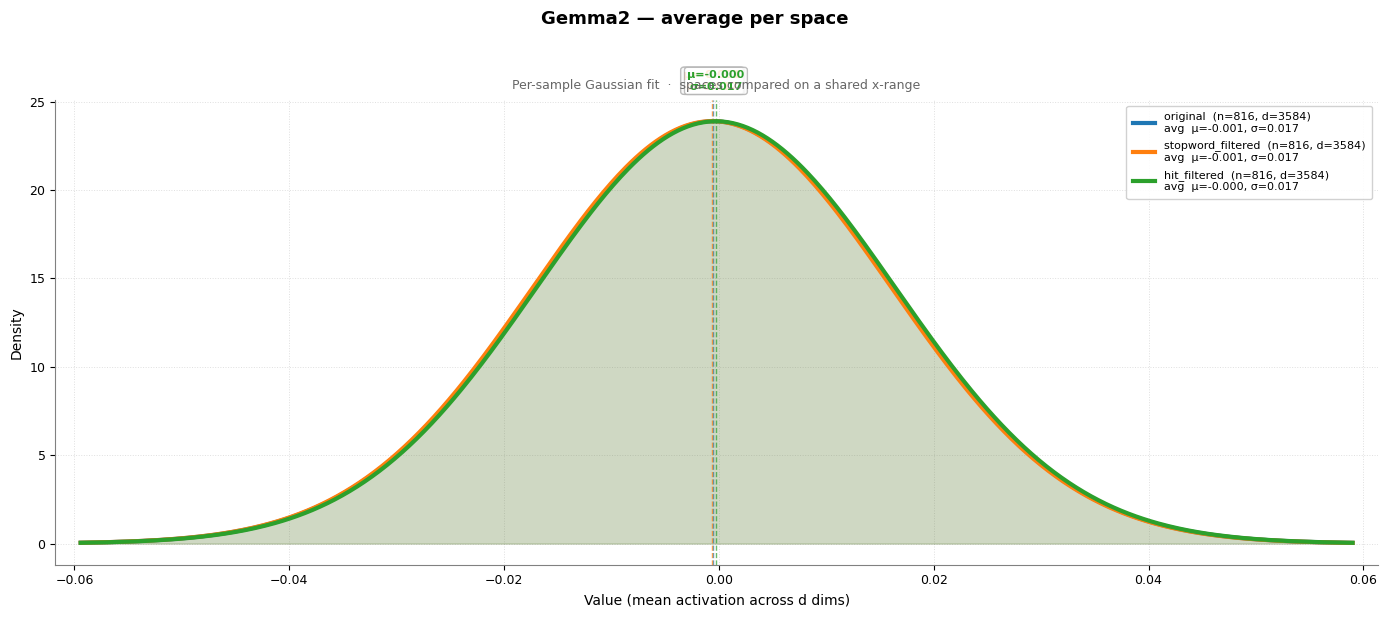

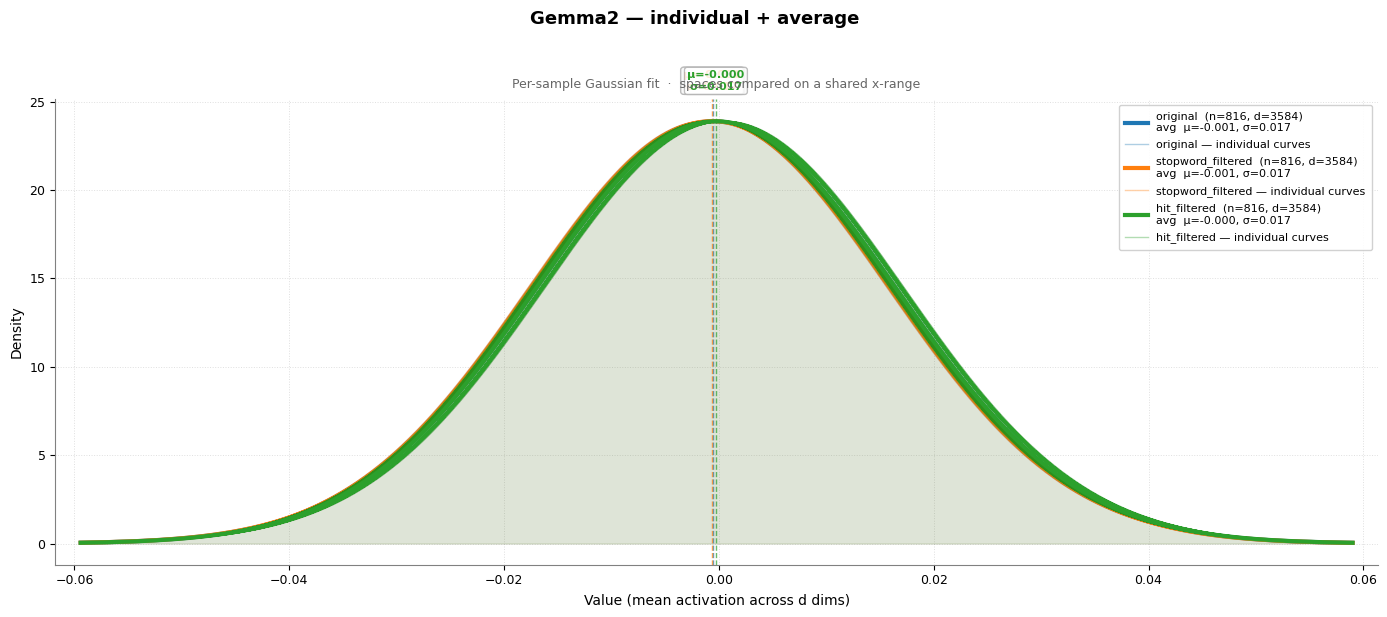


Distribution Shift Analysis Summary — Gemma2
--------------------------------------------------------------------------------
Total queries analyzed: 816
Embedding dimension: 3584
Key insights:

  ORIGINAL
    Average μ (mean embedding magnitude):  -0.0005
    Average σ (std of embeddings):         0.0167
    Spread of μ values (std(μ)):           0.0002
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          23.896270

  STOPWORD_FILTERED
    Average μ (mean embedding magnitude):  -0.0006
    Average σ (std of embeddings):         0.0167
    Spread of μ values (std(μ)):           0.0002
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          23.901756

  HIT_FILTERED
    Average μ (mean embedding magnitude):  -0.0003
    Average σ (std of embeddings):         0.0167
    Spread of μ values (std(μ)):           0.0004
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          23.8

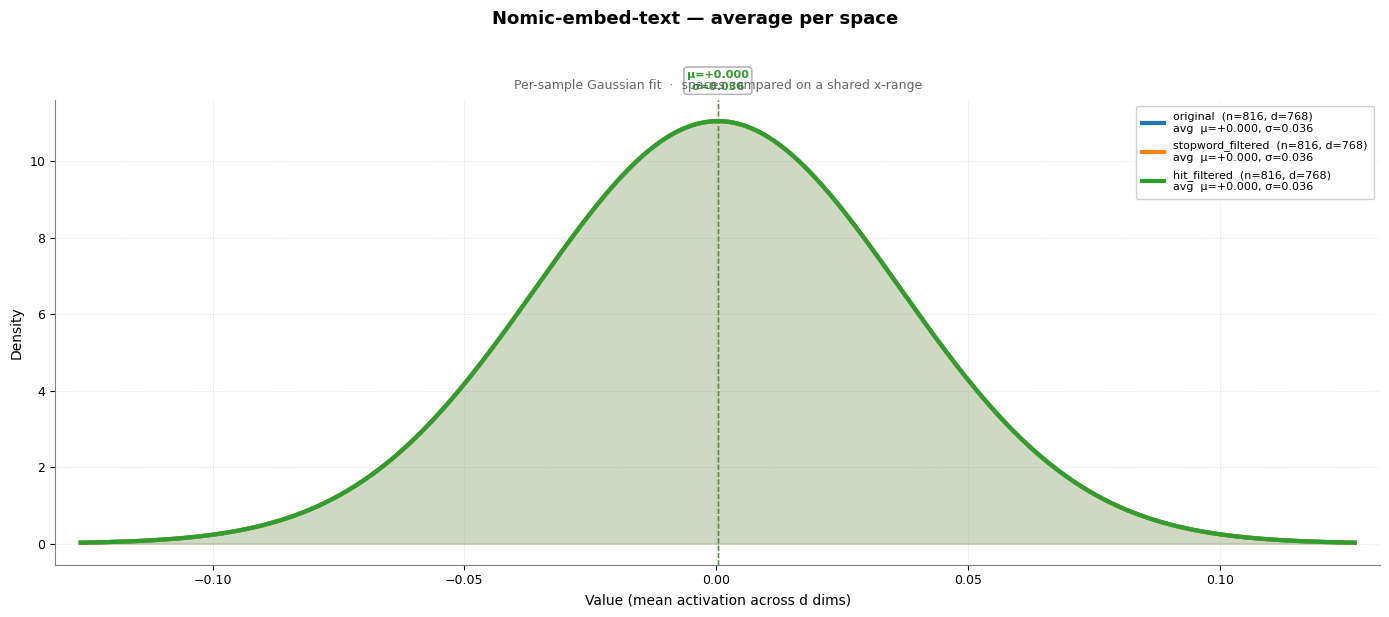

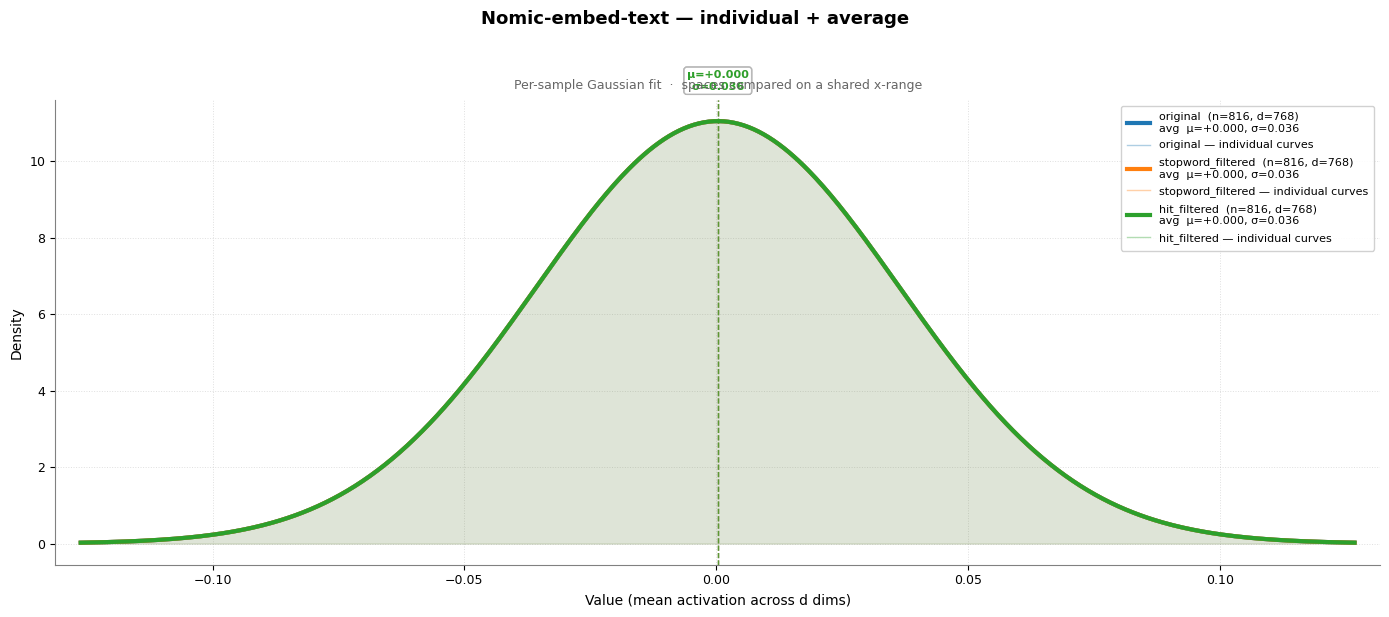


Distribution Shift Analysis Summary — Nomic-embed-text
--------------------------------------------------------------------------------
Total queries analyzed: 816
Embedding dimension: 768
Key insights:

  ORIGINAL
    Average μ (mean embedding magnitude):  +0.0003
    Average σ (std of embeddings):         0.0361
    Spread of μ values (std(μ)):           0.0000
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          11.056242

  STOPWORD_FILTERED
    Average μ (mean embedding magnitude):  +0.0003
    Average σ (std of embeddings):         0.0361
    Spread of μ values (std(μ)):           0.0001
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          11.056227

  HIT_FILTERED
    Average μ (mean embedding magnitude):  +0.0003
    Average σ (std of embeddings):         0.0361
    Spread of μ values (std(μ)):           0.0000
    Spread of σ values (std(σ)):           0.0000
    Peak density:                     

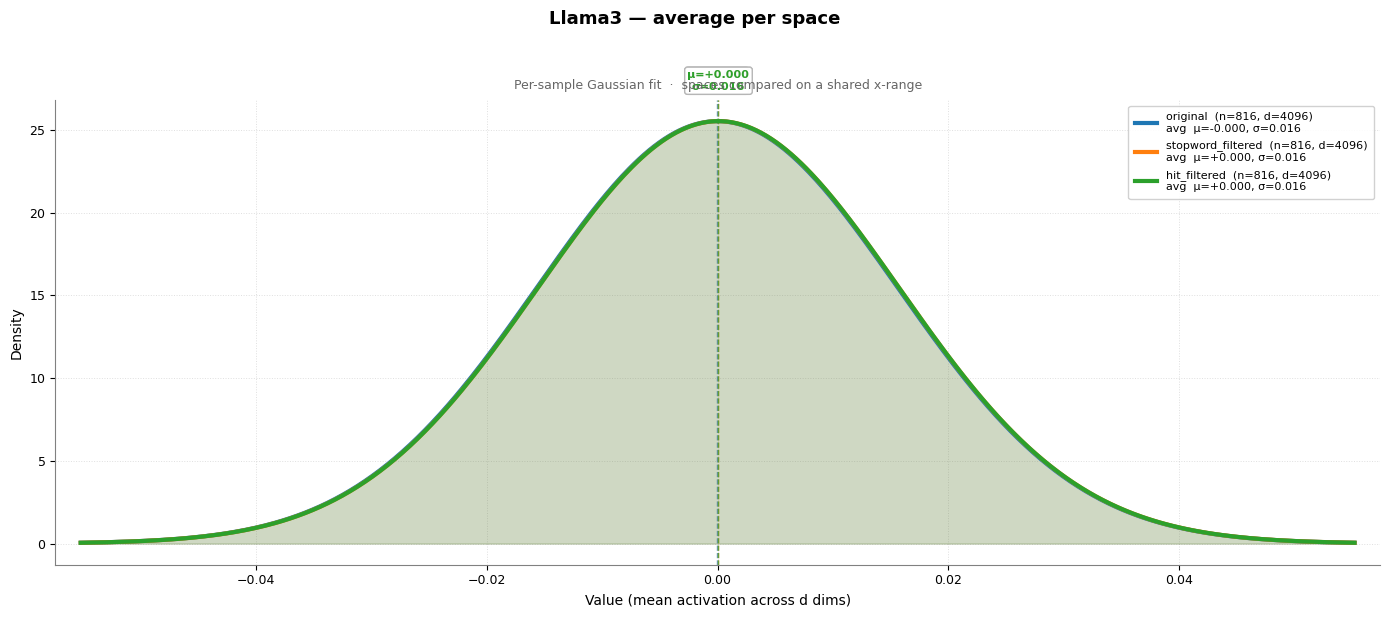

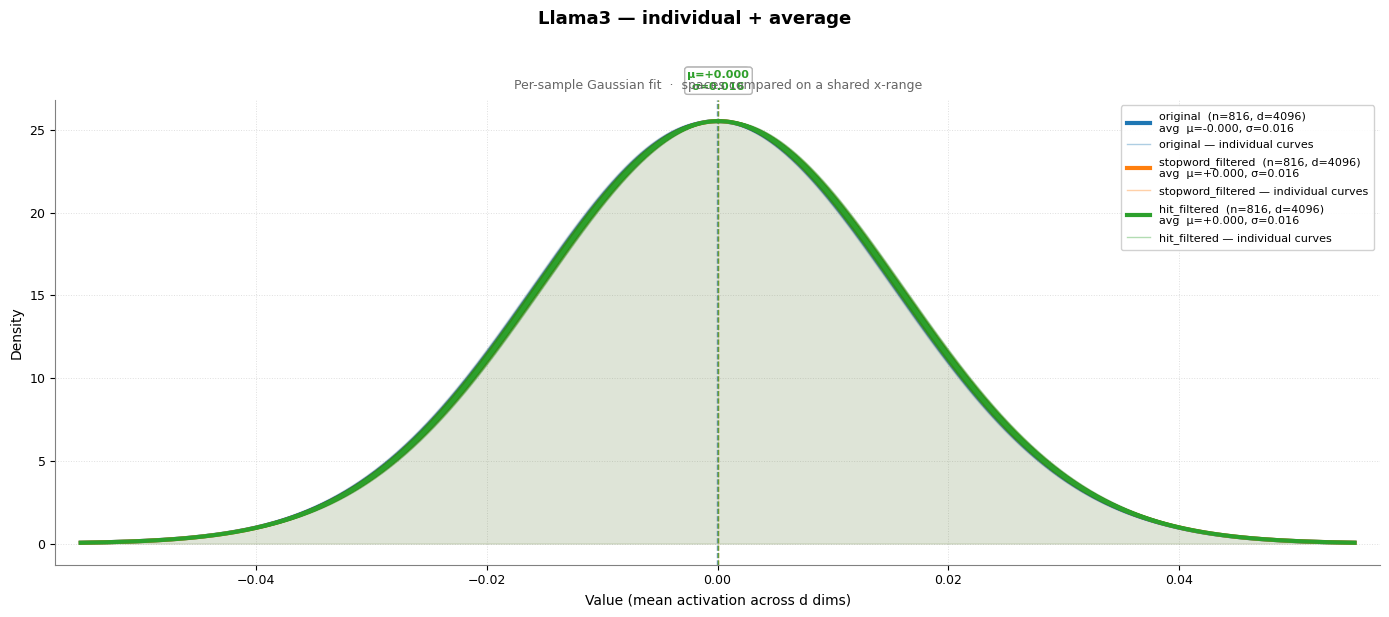


Distribution Shift Analysis Summary — Llama3
--------------------------------------------------------------------------------
Total queries analyzed: 816
Embedding dimension: 4096
Key insights:

  ORIGINAL
    Average μ (mean embedding magnitude):  -0.0000
    Average σ (std of embeddings):         0.0156
    Spread of μ values (std(μ)):           0.0001
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          25.533496

  STOPWORD_FILTERED
    Average μ (mean embedding magnitude):  +0.0001
    Average σ (std of embeddings):         0.0156
    Spread of μ values (std(μ)):           0.0001
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          25.533578

  HIT_FILTERED
    Average μ (mean embedding magnitude):  +0.0001
    Average σ (std of embeddings):         0.0156
    Spread of μ values (std(μ)):           0.0002
    Spread of σ values (std(σ)):           0.0000
    Peak density:                          25.5

In [15]:

# ─────────────────────────────────────────────────────────────────────────────
# Visualize embedding distribution shift between spaces (per model)
# ─────────────────────────────────────────────────────────────────────────────
# This plots the three embedding spaces with:
#   • Light curves: individual per-sample Gaussians (one per query embedding)
#   • Bold curves: average Gaussian per embedding space (highlights the shift)
#
# The plot shows how distributions differ:
#   - original         : full unfiltered query embeddings
#   - stopword_filtered: queries with stopwords removed
#   - hit_filtered     : queries with only high-informative tokens (cosine ≥ threshold)

from matplotlib import pyplot as plt


figs_by_model = {}
summary_by_model = {}

for display_name, spaces in embedding_spaces_by_model.items():
    safe_name = display_name.replace('/', '_')
    cq = couple_queries_by_model[display_name]

    print("\n" + "=" * 80)
    print(f"[model] {display_name}")
    print("=" * 80)

    # Convert this model's embedding_spaces (torch tensors) to numpy for plotting
    embedding_spaces_for_plot = {
        k: v.cpu().numpy() if isinstance(v, torch.Tensor) else v
        for k, v in spaces.items()
    }

    # Create visualizations with distribution shift highlighting
    fig_avg, fig_all, summary = plot_embedding_shift(
        embedding_spaces_for_plot,
        model_name=display_name,
        figsize=(14, 6),
        alpha_indiv=0.06,        # very light individual curves
        lw_indiv=1.0,            # thin individual lines
        lw_avg=3.0,              # bold average Gaussian lines
        n_sigma=3.5,
        save_prefix=f"embedding_distribution_shift_{safe_name}",
        dpi=150,
    )

    plt.show()

    figs_by_model[display_name] = (fig_avg, fig_all)
    summary_by_model[display_name] = summary

    print(f"\nDistribution Shift Analysis Summary — {display_name}")
    print("-" * 80)
    print(f"Total queries analyzed: {len(cq)}")
    print(f"Embedding dimension: {embedding_spaces_for_plot['original'].shape[1]}")
    print("Key insights:")
    for name in embedding_spaces_for_plot.keys():
        s = summary[name]
        print(f"\n  {name.upper()}")
        print(f"    Average μ (mean embedding magnitude):  {s['avg_mu']:+.4f}")
        print(f"    Average σ (std of embeddings):         {s['avg_sig']:.4f}")
        print(f"    Spread of μ values (std(μ)):           {s['std_mu']:.4f}")
        print(f"    Spread of σ values (std(σ)):           {s['std_sig']:.4f}")
        print(f"    Peak density:                          {s['peak_density']:.6f}")


In [16]:
# ── Sanity check: are the three spaces actually DIFFERENT embeddings? ─────────
# The distribution_shift plot only looks at the per-vector component mean (μ) and
# std (σ). For L2-normalized embeddings those are fixed by the dimension alone
# (μ≈0, σ≈1/sqrt(d)) regardless of the text — that's why all three curves overlap.
# Here we instead compare the embeddings DIRECTLY to confirm they differ.
for display_name, cq in couple_queries_by_model.items():
    orig = torch.stack([item[3] for item in cq])  # original full-query embedding
    sw   = torch.stack([item[5] for item in cq])  # stop-word-filtered embedding
    hit  = torch.stack([item[7] for item in cq])  # HIT-filtered embedding

    d = orig.shape[1]
    print(f"\n=== {display_name}  (n={orig.shape[0]}, d={d}) ===")

    # 1) Are the texts actually different?
    n_sw_changed  = sum(item[1] != item[4] for item in cq)
    n_hit_changed = sum(item[1] != item[6] for item in cq)
    print(f"queries where SW text  differs from original: {n_sw_changed}/{len(cq)}")
    print(f"queries where HIT text differs from original: {n_hit_changed}/{len(cq)}")

    # 2) Are the embedding TENSORS actually different?
    print(f"orig vs sw : exactly equal tensors? {torch.allclose(orig, sw)}")
    print(f"orig vs hit: exactly equal tensors? {torch.allclose(orig, hit)}")

    # 3) Content-sensitive metric: cosine similarity to the original embedding.
    cos_sw  = F.cosine_similarity(orig, sw,  dim=1)
    cos_hit = F.cosine_similarity(orig, hit, dim=1)
    print(f"cosine(orig, sw ): mean={cos_sw.mean():.4f}  min={cos_sw.min():.4f}")
    print(f"cosine(orig, hit): mean={cos_hit.mean():.4f}  min={cos_hit.min():.4f}")

    # 4) Why the μ/σ plot looks identical: σ ≈ 1/sqrt(d) for unit-norm vectors.
    print(f"L2 norm (orig) mean={orig.norm(dim=1).mean():.4f}  -> 1/sqrt(d)={1/d**0.5:.4f}")



=== Gemma2  (n=816, d=3584) ===
queries where SW text  differs from original: 816/816
queries where HIT text differs from original: 816/816
orig vs sw : exactly equal tensors? False
orig vs hit: exactly equal tensors? False
cosine(orig, sw ): mean=0.7303  min=0.3103
cosine(orig, hit): mean=0.4449  min=0.2474
L2 norm (orig) mean=1.0000  -> 1/sqrt(d)=0.0167

=== Nomic-embed-text  (n=816, d=768) ===
queries where SW text  differs from original: 816/816
queries where HIT text differs from original: 11/816
orig vs sw : exactly equal tensors? False
orig vs hit: exactly equal tensors? True
cosine(orig, sw ): mean=0.9339  min=0.7766
cosine(orig, hit): mean=1.0000  min=1.0000
L2 norm (orig) mean=1.0000  -> 1/sqrt(d)=0.0361

=== Llama3  (n=816, d=4096) ===
queries where SW text  differs from original: 816/816
queries where HIT text differs from original: 816/816
orig vs sw : exactly equal tensors? False
orig vs hit: exactly equal tensors? False
cosine(orig, sw ): mean=0.6975  min=0.2867
cosine(


[model] Gemma2
Saved: embedding_distribution_shift_Gemma2_content_shift.png


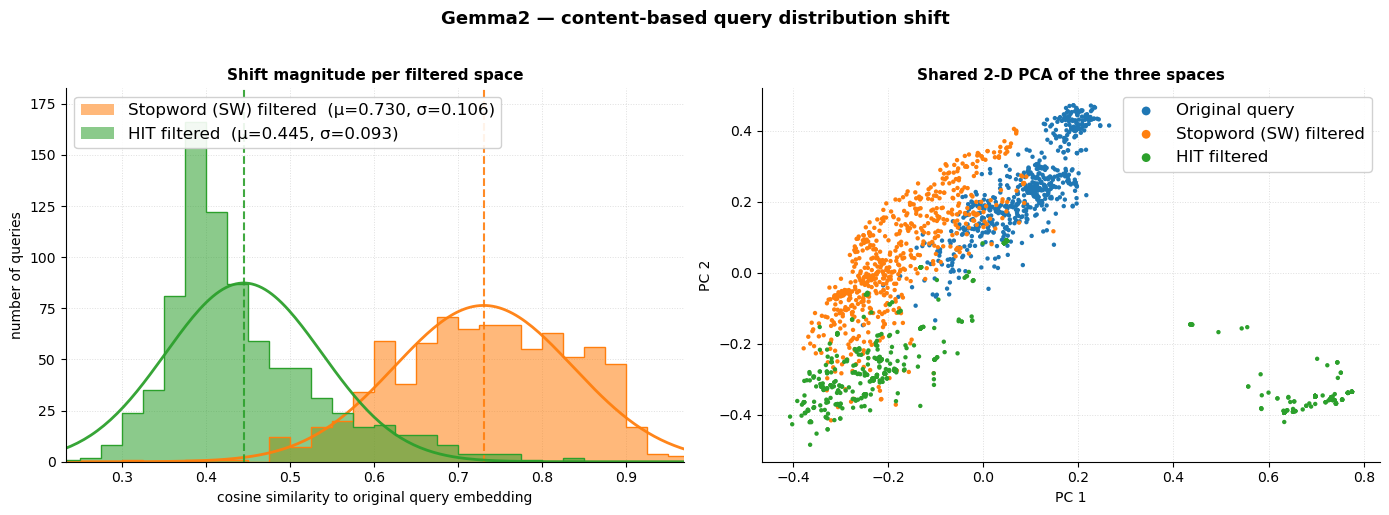


[model] Nomic-embed-text
Saved: embedding_distribution_shift_Nomic-embed-text_content_shift.png


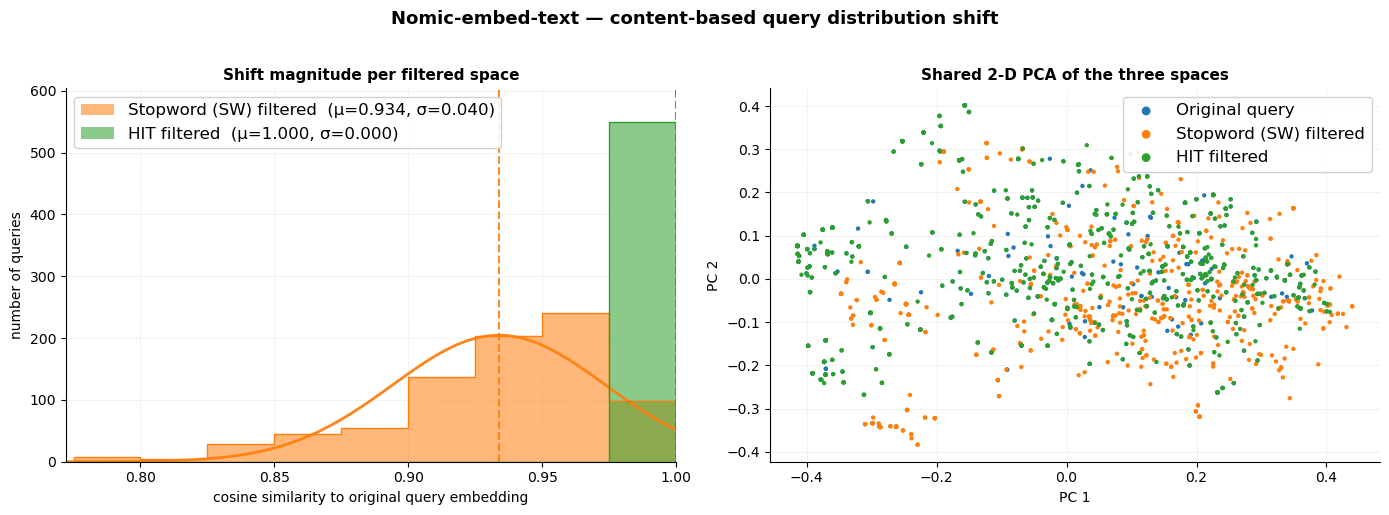


[model] Llama3
Saved: embedding_distribution_shift_Llama3_content_shift.png


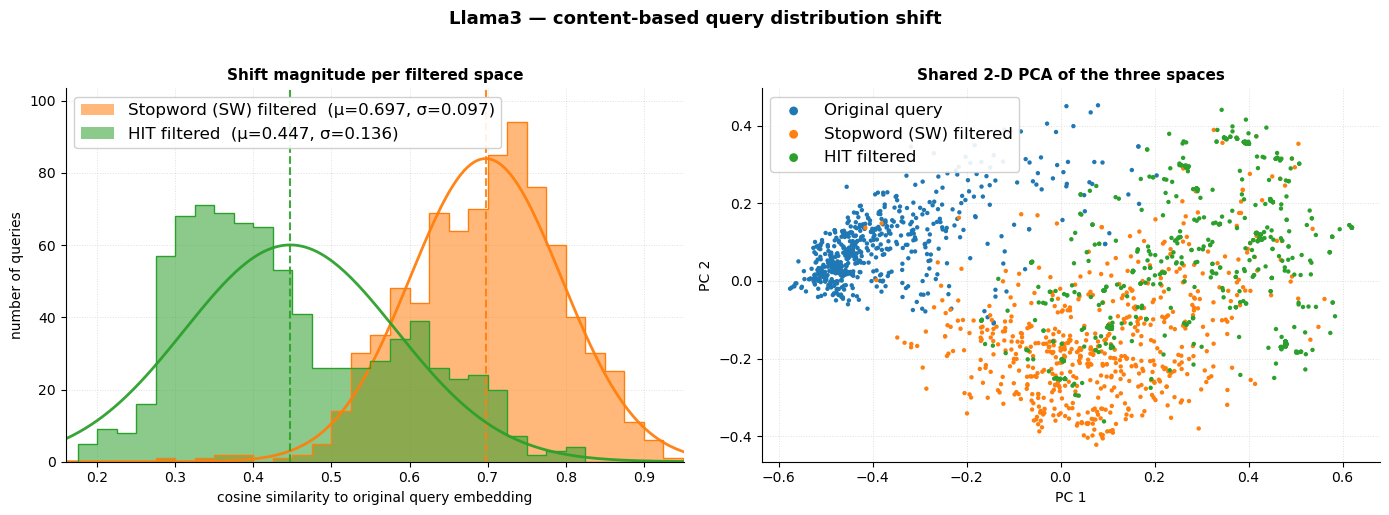

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Content-sensitive distribution shift (per model)
# ─────────────────────────────────────────────────────────────────────────────
# The Gaussian μ/σ plot above is blind to semantic shift (it only reflects 1/sqrt(d)
# for unit-norm vectors). These two views DO reflect how the spaces differ:
#   • Left : distribution of cosine similarity of each filtered query to its original
#            (cos=1 means "no shift"; lower means the embedding moved).
#   • Right: shared 2-D PCA scatter of the three spaces (fit on the stacked points).
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from sklearn.decomposition import PCA

_SHIFT_COLORS = {"Original query": "#1f77b4", "Stopword (SW) filtered": "#ff7f0e", "HIT filtered": "#2ca02c"}
# Map the raw space keys to the display labels used in the legend / colours.
_SHIFT_LABELS = {"original": "Original query",
                 "stopword_filtered": "Stopword (SW) filtered",
                 "hit_filtered": "HIT filtered"}


def plot_content_shift(spaces, *, model_name=None, figsize=(14, 5),
                       save_prefix=None, dpi=150, max_scatter=600):
    """Plot cosine-similarity-to-original histograms + a shared 2-D PCA scatter."""
    names = [_SHIFT_LABELS.get(k, k) for k in spaces.keys()]
    arrs = {_SHIFT_LABELS.get(k, k): (v.cpu().numpy() if isinstance(v, torch.Tensor) else np.asarray(v))
            for k, v in spaces.items()}
    orig = arrs["Original query"]
    prefix = f"{model_name} — " if model_name else ""

    fig, (ax_hist, ax_pca) = plt.subplots(1, 2, figsize=figsize)

    # ── Left: cosine similarity of each space to the original ────────────────
    def _cos_to_orig(a):
        num = (a * orig).sum(axis=1)
        den = np.linalg.norm(a, axis=1) * np.linalg.norm(orig, axis=1) + 1e-12
        return num / den

    n_bins, hist_range = 40, (0, 1)
    bin_width = (hist_range[1] - hist_range[0]) / n_bins
    fit_xs = np.linspace(*hist_range, 256)
    cos_min, cos_max = 1.0, 0.0
    max_count = 0.0
    for name in names:
        if name == "Original query":
            continue
        cos = _cos_to_orig(arrs[name])
        cos_min, cos_max = min(cos_min, float(cos.min())), max(cos_max, float(cos.max()))
        mu, sigma = float(cos.mean()), float(cos.std())
        colour = _SHIFT_COLORS.get(name, "#888")
        counts, _, _ = ax_hist.hist(cos, bins=n_bins, range=hist_range, alpha=0.55,
                                    color=colour,
                                    label=f"{name}  (μ={mu:.3f}, σ={sigma:.3f})")
        # Solid outline so each distribution stays crisp while the overlap blends.
        ax_hist.hist(cos, bins=n_bins, range=hist_range, histtype="step",
                     color=colour, lw=1.6, alpha=1.0)
        max_count = max(max_count, float(counts.max()))
        # Gaussian fit overlay (skip degenerate σ≈0 spikes that would blow up the y-axis).
        if sigma > 1e-4:
            fit_y = norm.pdf(fit_xs, loc=mu, scale=sigma) * len(cos) * bin_width
            ax_hist.plot(fit_xs, fit_y, color=colour, lw=2, alpha=0.95)
            max_count = max(max_count, float(fit_y.max()))
        ax_hist.axvline(mu, color=colour, lw=1.5, linestyle="--", alpha=0.9)
    # Strip the x-axis to where the data actually lives (small padding).
    pad = 0.02 * max(cos_max - cos_min, 1e-3)
    ax_hist.set_xlim(max(0.0, cos_min - pad), min(1.0, cos_max + pad))
    # Fit the y-axis to the real bar heights so an outlier spike can't hide the rest.
    ax_hist.set_ylim(0, max_count * 1.1)
    ax_hist.set_xlabel("cosine similarity to original query embedding", fontsize=10)
    ax_hist.set_ylabel("number of queries", fontsize=10)
    ax_hist.set_title("Shift magnitude per filtered space", fontsize=11, fontweight="bold")
    ax_hist.grid(True, linestyle=":", linewidth=0.7, alpha=0.4)
    ax_hist.set_axisbelow(True)
    ax_hist.spines[["top", "right"]].set_visible(False)
    ax_hist.legend(fontsize=12, framealpha=0.9, loc="upper left")

    # ── Right: shared 2-D PCA of the three spaces ────────────────────────────
    stacked = np.vstack([arrs[n] for n in names])
    coords = PCA(n_components=2, random_state=0).fit_transform(stacked)
    offsets = np.cumsum([0] + [len(arrs[n]) for n in names])
    rng = np.random.default_rng(0)
    for i, name in enumerate(names):
        pts = coords[offsets[i]:offsets[i + 1]]
        if len(pts) > max_scatter:
            sel = rng.choice(len(pts), size=max_scatter, replace=False)
            pts = pts[sel]
        ax_pca.scatter(pts[:, 0], pts[:, 1], s=10, alpha=1.0,
                       color=_SHIFT_COLORS.get(name, "#888"), label=name,
                       edgecolors="none")
    ax_pca.set_xlabel("PC 1", fontsize=10)
    ax_pca.set_ylabel("PC 2", fontsize=10)
    ax_pca.set_title("Shared 2-D PCA of the three spaces", fontsize=11, fontweight="bold")
    ax_pca.grid(True, linestyle=":", linewidth=0.7, alpha=0.4)
    ax_pca.set_axisbelow(True)
    ax_pca.spines[["top", "right"]].set_visible(False)
    ax_pca.legend(fontsize=12, framealpha=0.9, loc="best", markerscale=2)

    fig.suptitle(f"{prefix}content-based query distribution shift", fontsize=13,
                 fontweight="bold", y=1.02)
    fig.tight_layout()

    if save_prefix:
        fig.savefig(f"{save_prefix}_content_shift.png", dpi=dpi, bbox_inches="tight")
        print(f"Saved: {save_prefix}_content_shift.png")
    return fig


content_figs_by_model = {}
for display_name, spaces in embedding_spaces_by_model.items():
    safe_name = display_name.replace('/', '_')
    print("\n" + "=" * 80)
    print(f"[model] {display_name}")
    print("=" * 80)
    fig = plot_content_shift(
        spaces,
        model_name=display_name,
        figsize=(14, 5),
        save_prefix=f"embedding_distribution_shift_{safe_name}",
        dpi=150,
    )
    plt.show()
    content_figs_by_model[display_name] = fig